In [ ]:
import numpy as np
import pandas as pd
import re
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('All libraries loaded!')

TensorFlow version: 2.20.0
All libraries loaded!


In [ ]:
#code for ansh
from google.colab import drive
drive.mount('/content/drive')

NAZARIO_PATH = '/content/drive/MyDrive/CS271/Nazario.csv'
SPAM_PATH    = '/content/drive/MyDrive/CS271/spam_ham_dataset.csv'

# NAZARIO_PATH = r'C:\Users\leeja\Downloads\Phishing-Email-Detection-Under-Adversarial-Attack-Comparing-MLP-Naive-Bayes-and-Logistic-Regression\Nazario.csv\Nazario.csv'
# SPAM_PATH    = r'C:\Users\leeja\Downloads\Phishing-Email-Detection-Under-Adversarial-Attack-Comparing-MLP-Naive-Bayes-and-Logistic-Regression\spam_ham_dataset.csv\spam_ham_dataset.csv'

nazario = pd.read_csv(NAZARIO_PATH)
spam    = pd.read_csv(SPAM_PATH)

print('Nazario columns:', nazario.columns.tolist())
print('Spam columns:   ', spam.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Nazario columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Spam columns:    ['Unnamed: 0', 'label', 'text', 'label_num']


In [ ]:
nazario_clean = nazario[['body', 'label']].copy()
nazario_clean.columns = ['text', 'label']

spam_clean = spam[['text', 'label_num']].copy()
spam_clean.columns = ['text', 'label']

df = pd.concat([nazario_clean, spam_clean], ignore_index=True)
df.dropna(inplace=True)
df['label'] = df['label'].astype(int)
df.reset_index(drop=True, inplace=True)

print(f'Total samples : {len(df)}')
print(df['label'].value_counts())
print('0 = Legit  |  1 = Phishing/Spam')

Total samples : 6736
label
0    3672
1    3064
Name: count, dtype: int64
0 = Legit  |  1 = Phishing/Spam


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
print('Cleaning done!')
print('Sample:', df['text_clean'].iloc[0][:200])

Cleaning done!
Sample: this text is part of the internal format of your mail folder and is not a real message it is created automatically by the mail system software if deleted important folder data will be lost and it will


In [ ]:
X_text = df['text_clean'].values
y      = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train_text)} samples')
print(f'Test : {len(X_test_text)} samples')

Train: 5388 samples
Test : 1348 samples


In [ ]:
# TF-IDF for NB and LR — fewer features to save RAM
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print('TF-IDF shape:', X_train_tfidf.shape)

TF-IDF shape: (5388, 5000)


In [ ]:
# Character substitution
CHAR_MAP = {'a':'@', 'o':'0', 'i':'1', 'e':'3', 's':'$', 'l':'1', 'g':'9', 't':'7'}

def substitute_chars(text):
    return ''.join(CHAR_MAP.get(c, c) for c in str(text))

X_test_manip_text  = np.array([substitute_chars(t) for t in X_test_text])
X_test_manip_tfidf = tfidf.transform(X_test_manip_text)

print('Original   :', X_test_text[0][:80])
print('Manipulated:', X_test_manip_text[0][:80])

Original   : subject new turn ons tom production commenced to flow as stated below please cre
Manipulated: $ubj3c7 n3w 7urn 0n$ 70m pr0duc710n c0mm3nc3d 70 f10w @$ $7@73d b310w p13@$3 cr3


In [ ]:
# Robust training data for MLP
X_train_manip = [substitute_chars(t) for t in X_train_text]  # plain list, no np.array

X_train_robust_text = list(X_train_text) + X_train_manip
y_train_robust      = np.concatenate([y_train, y_train])

tfidf_robust    = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
X_train_robust  = tfidf_robust.fit_transform(X_train_robust_text)

X_test_robust_clean = tfidf_robust.transform(X_test_text)
X_test_robust_manip = tfidf_robust.transform(X_test_manip_text)

print(f'Robust training size: {X_train_robust.shape}')

Robust training size: (10776, 5000)


In [ ]:
# Helper functions
results_clean = {}
results_manip = {}
results_adv   = {}
roc_data      = {}

def evaluate(name, y_true, y_pred, y_prob, split='clean'):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    fnr = 1 - tpr
    eer = float(fpr[np.nanargmin(np.abs(fnr - fpr))])

    metrics = dict(Accuracy=acc, F1=f1, Precision=prec, Recall=rec, AUC=roc_auc, EER=eer)

    if split == 'clean':
        results_clean[name] = metrics
    elif split == 'manip':
        results_manip[name] = metrics
    else:
        results_adv[name] = metrics

    if name not in roc_data:
        roc_data[name] = {}
    roc_data[name][split] = (fpr, tpr, roc_auc)

    print(f'\n=== {name}  [{split.upper()}] ===')
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Phishing']))
    print(f'AUC : {roc_auc:.4f}')
    print(f'EER : {eer:.4f}  (lower is better)')
    return metrics


def plot_cm(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Phishing'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=True)
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history.history['accuracy']) + 1)

    axes[0].plot(epochs, history.history['accuracy'],     label='Train', linewidth=2, color='#2196F3')
    axes[0].plot(epochs, history.history['val_accuracy'], label='Val',   linewidth=2, color='#2196F3', linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy per Epoch', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(epochs, history.history['loss'],     label='Train', linewidth=2, color='tomato')
    axes[1].plot(epochs, history.history['val_loss'], label='Val',   linewidth=2, color='tomato', linestyle='--')
    axes[1].set_title(f'{model_name} — Loss per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Binary Cross-Entropy Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

print('Helpers ready!')

Helpers ready!


Training Naive Bayes...

=== Naive Bayes  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.95      0.93      0.94       735
    Phishing       0.92      0.95      0.93       613

    accuracy                           0.94      1348
   macro avg       0.94      0.94      0.94      1348
weighted avg       0.94      0.94      0.94      1348

AUC : 0.9842
EER : 0.0571  (lower is better)


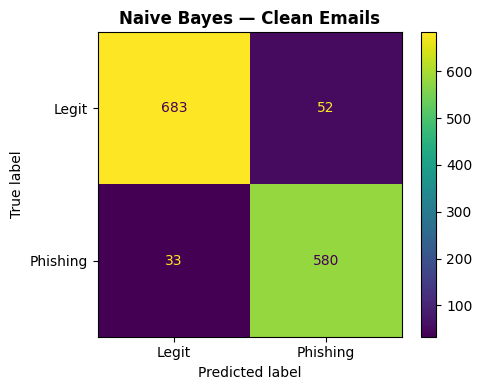

In [ ]:
# Naive Bayes — Clean
print('Training Naive Bayes...')
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred_clean = nb.predict(X_test_tfidf)
nb_prob_clean = nb.predict_proba(X_test_tfidf)[:, 1]
evaluate('Naive Bayes', y_test, nb_pred_clean, nb_prob_clean, split='clean')
plot_cm(y_test, nb_pred_clean, 'Naive Bayes — Clean Emails')


=== Naive Bayes  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.71      0.59      0.64       735
    Phishing       0.59      0.71      0.64       613

    accuracy                           0.64      1348
   macro avg       0.65      0.65      0.64      1348
weighted avg       0.65      0.64      0.64      1348

AUC : 0.7330
EER : 0.3456  (lower is better)


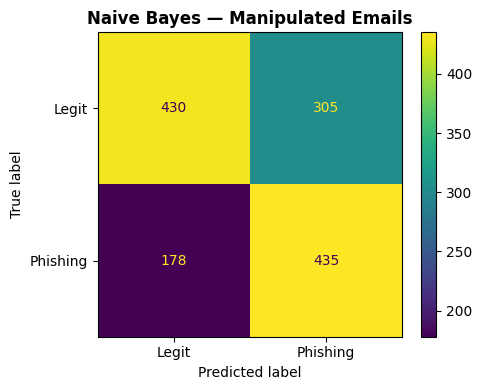

In [ ]:
# Naive Bayes — Manipulated
nb_pred_manip = nb.predict(X_test_manip_tfidf)
nb_prob_manip = nb.predict_proba(X_test_manip_tfidf)[:, 1]
evaluate('Naive Bayes', y_test, nb_pred_manip, nb_prob_manip, split='manip')
plot_cm(y_test, nb_pred_manip, 'Naive Bayes — Manipulated Emails')

Training Logistic Regression...

=== Logistic Regression  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.99      0.96      0.97       735
    Phishing       0.95      0.99      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC : 0.9970
EER : 0.0259  (lower is better)


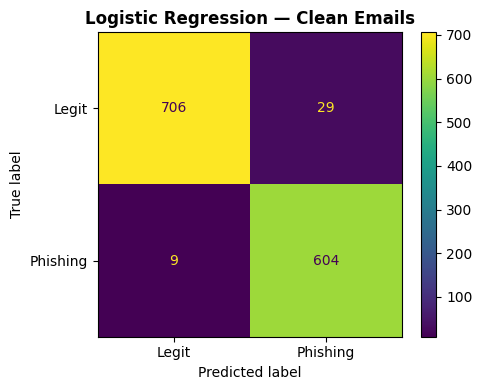

In [ ]:
# Logistic Regression — Clean
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

lr_pred_clean = lr.predict(X_test_tfidf)
lr_prob_clean = lr.predict_proba(X_test_tfidf)[:, 1]
evaluate('Logistic Regression', y_test, lr_pred_clean, lr_prob_clean, split='clean')
plot_cm(y_test, lr_pred_clean, 'Logistic Regression — Clean Emails')


=== Logistic Regression  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.89      0.29      0.43       735
    Phishing       0.53      0.96      0.68       613

    accuracy                           0.59      1348
   macro avg       0.71      0.62      0.56      1348
weighted avg       0.73      0.59      0.55      1348

AUC : 0.7998
EER : 0.2585  (lower is better)


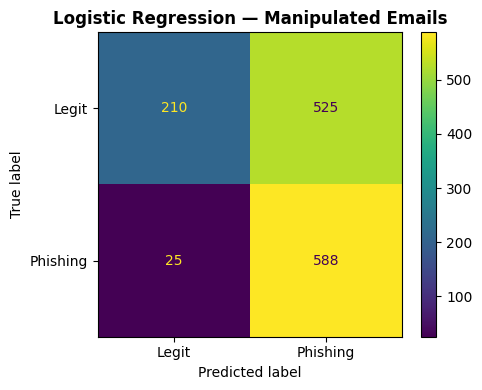

In [ ]:
# Logistic Regression — Manipulated
lr_pred_manip = lr.predict(X_test_manip_tfidf)
lr_prob_manip = lr.predict_proba(X_test_manip_tfidf)[:, 1]
evaluate('Logistic Regression', y_test, lr_pred_manip, lr_prob_manip, split='manip')
plot_cm(y_test, lr_pred_manip, 'Logistic Regression — Manipulated Emails')

In [ ]:
# ── ROBUST NB AND LR ──────────────────────────────────────────
# Retrain NB and LR on robust data (clean + manipulated)
# so we can compare all 3 models under the same conditions

# Robust TF-IDF for NB and LR (same vectorizer used for MLP)
X_train_robust_nb = tfidf_robust.transform(list(X_train_text) + [substitute_chars(t) for t in X_train_text])

print("Training Robust Naive Bayes...")
nb_robust = MultinomialNB()
nb_robust.fit(X_train_robust_nb, y_train_robust)
print("Done!")

print("Training Robust Logistic Regression...")
lr_robust = LogisticRegression(max_iter=1000, random_state=42)
lr_robust.fit(X_train_robust_nb, y_train_robust)
print("Done!")

Training Robust Naive Bayes...
Done!
Training Robust Logistic Regression...
Done!



=== Naive Bayes (Robust)  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.95      0.93      0.94       735
    Phishing       0.92      0.94      0.93       613

    accuracy                           0.94      1348
   macro avg       0.94      0.94      0.94      1348
weighted avg       0.94      0.94      0.94      1348

AUC : 0.9829
EER : 0.0626  (lower is better)


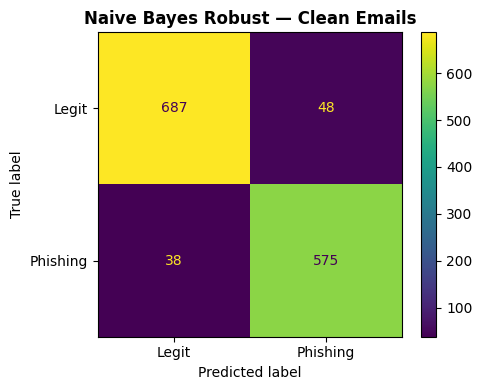

In [ ]:
# Robust NB — Clean
nb_r_prob_clean = nb_robust.predict_proba(X_test_robust_clean)[:, 1]
nb_r_pred_clean = nb_robust.predict(X_test_robust_clean)
evaluate("Naive Bayes (Robust)", y_test, nb_r_pred_clean, nb_r_prob_clean, split="clean")
plot_cm(y_test, nb_r_pred_clean, "Naive Bayes Robust — Clean Emails")


=== Naive Bayes (Robust)  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.97      0.91      0.94       735
    Phishing       0.90      0.96      0.93       613

    accuracy                           0.93      1348
   macro avg       0.93      0.93      0.93      1348
weighted avg       0.93      0.93      0.93      1348

AUC : 0.9829
EER : 0.0680  (lower is better)


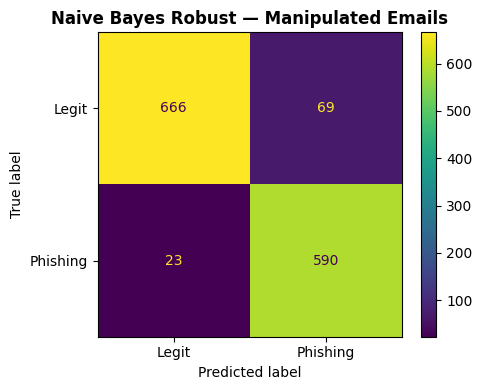

In [ ]:
# Robust NB — Manipulated
nb_r_prob_manip = nb_robust.predict_proba(X_test_robust_manip)[:, 1]
nb_r_pred_manip = nb_robust.predict(X_test_robust_manip)
evaluate("Naive Bayes (Robust)", y_test, nb_r_pred_manip, nb_r_prob_manip, split="manip")
plot_cm(y_test, nb_r_pred_manip, "Naive Bayes Robust — Manipulated Emails")


=== Logistic Regression (Robust)  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.98      0.97      0.97       735
    Phishing       0.96      0.97      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC : 0.9959
EER : 0.0340  (lower is better)


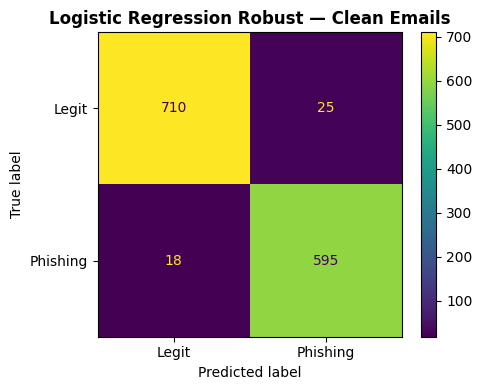

In [ ]:
# Robust LR — Clean
lr_r_prob_clean = lr_robust.predict_proba(X_test_robust_clean)[:, 1]
lr_r_pred_clean = lr_robust.predict(X_test_robust_clean)
evaluate("Logistic Regression (Robust)", y_test, lr_r_pred_clean, lr_r_prob_clean, split="clean")
plot_cm(y_test, lr_r_pred_clean, "Logistic Regression Robust — Clean Emails")


=== Logistic Regression (Robust)  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98       735
    Phishing       0.96      0.99      0.97       613

    accuracy                           0.98      1348
   macro avg       0.98      0.98      0.98      1348
weighted avg       0.98      0.98      0.98      1348

AUC : 0.9972
EER : 0.0272  (lower is better)


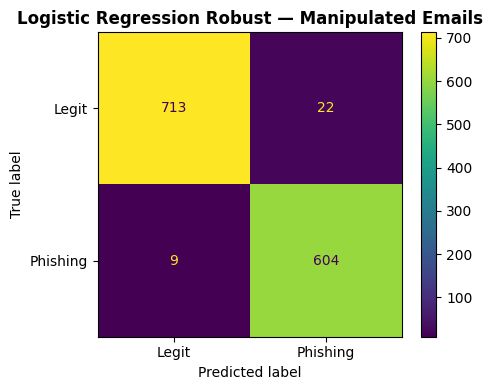

In [ ]:
# Robust LR — Manipulated
lr_r_prob_manip = lr_robust.predict_proba(X_test_robust_manip)[:, 1]
lr_r_pred_manip = lr_robust.predict(X_test_robust_manip)
evaluate("Logistic Regression (Robust)", y_test, lr_r_pred_manip, lr_r_prob_manip, split="manip")
plot_cm(y_test, lr_r_pred_manip, "Logistic Regression Robust — Manipulated Emails")

In [ ]:
# Build MLP — uses sparse_input=True to avoid RAM crash
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp(X_train_robust.shape[1])
mlp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,497 (2.48 MB)

 Trainable params: 650,497 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train MLP with sparse data
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print('Training MLP...')
mlp_history = mlp_model.fit(
    X_train_robust.toarray(), y_train_robust,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)
print(f'Training stopped at epoch {len(mlp_history.history["loss"])}')

Training MLP...
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9339 - loss: 0.2265 - val_accuracy: 0.9709 - val_loss: 0.0883
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.9740 - val_loss: 0.0749
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9934 - loss: 0.0198 - val_accuracy: 0.9753 - val_loss: 0.0755
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9984 - loss: 0.0086 - val_accuracy: 0.9759 - val_loss: 0.0896
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9979 - loss: 0.0059 - val_accuracy: 0.9771 - val_loss: 0.1111
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9987 - loss: 0.0038 - val_accuracy: 0.9790 - val_loss: 0.1053
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 0.9784 - val_loss: 0.1105
Training stopped at epoch 7


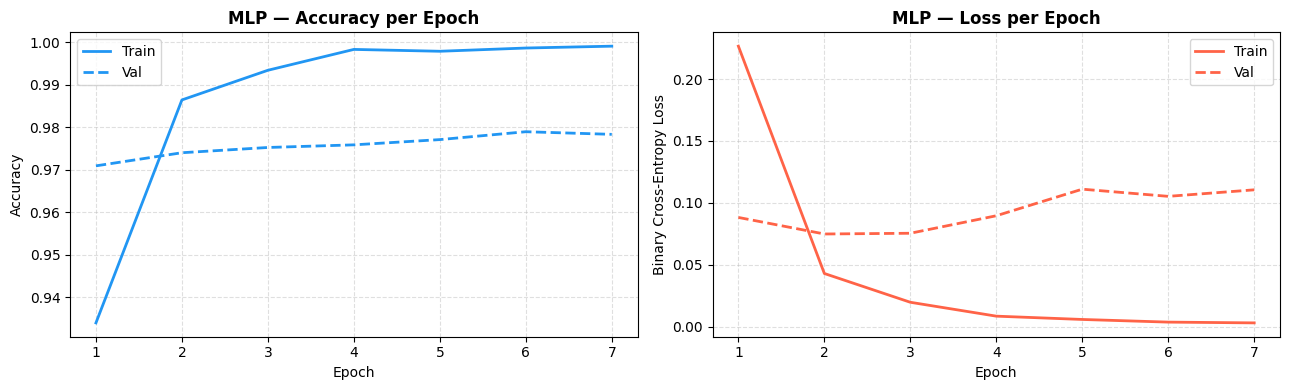

In [ ]:
plot_training_history(mlp_history, 'MLP')

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

=== MLP  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.97      0.98      0.98       735
    Phishing       0.98      0.97      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC : 0.9980
EER : 0.0231  (lower is better)


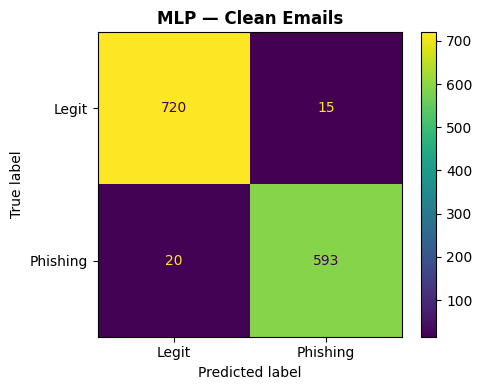

In [ ]:
# MLP — Clean
mlp_prob_clean = mlp_model.predict(X_test_robust_clean.toarray()).flatten()
mlp_pred_clean = (mlp_prob_clean >= 0.5).astype(int)
evaluate('MLP', y_test, mlp_pred_clean, mlp_prob_clean, split='clean')
plot_cm(y_test, mlp_pred_clean, 'MLP — Clean Emails')

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== MLP  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.97      0.98      0.97       735
    Phishing       0.97      0.96      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC : 0.9974
EER : 0.0259  (lower is better)


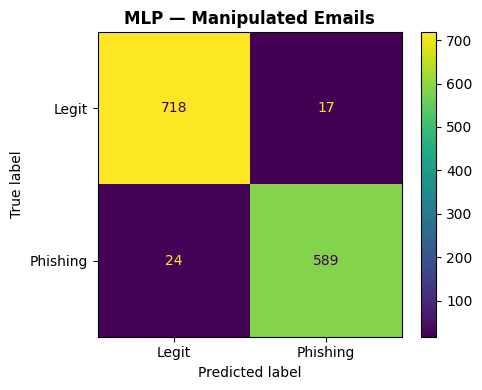

In [ ]:
# MLP — Manipulated
mlp_prob_manip = mlp_model.predict(X_test_robust_manip.toarray()).flatten()
mlp_pred_manip = (mlp_prob_manip >= 0.5).astype(int)
evaluate('MLP', y_test, mlp_pred_manip, mlp_prob_manip, split='manip')
plot_cm(y_test, mlp_pred_manip, 'MLP — Manipulated Emails')

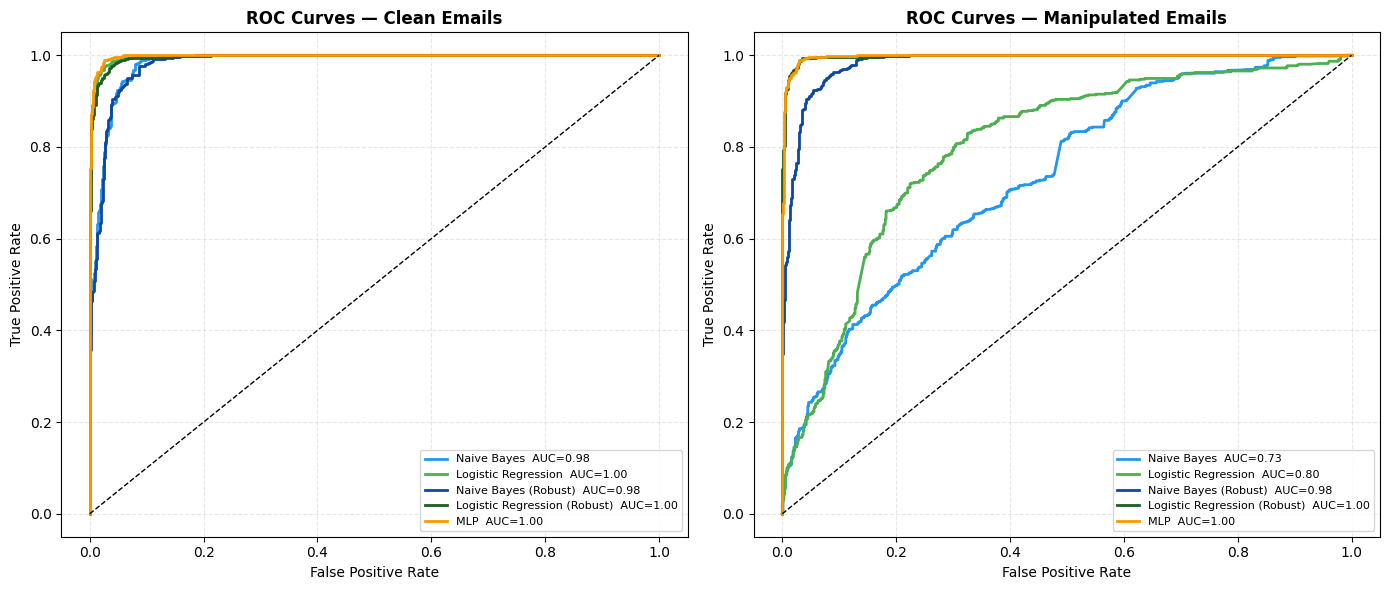

In [ ]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {
    'Naive Bayes': '#2196F3',
    'Logistic Regression': '#4CAF50',
    'MLP': '#FF9800',
    'Naive Bayes (Robust)': '#0D47A1',
    'Logistic Regression (Robust)': '#1B5E20'
}

for ax, split, title in zip(axes, ['clean', 'manip'], ['Clean Emails', 'Manipulated Emails']):
    for name, data in roc_data.items():
        if split in data:
            fpr, tpr, roc_auc = data[split]
            ax.plot(fpr, tpr, label=f'{name}  AUC={roc_auc:.2f}', color=colors[name], linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {title}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

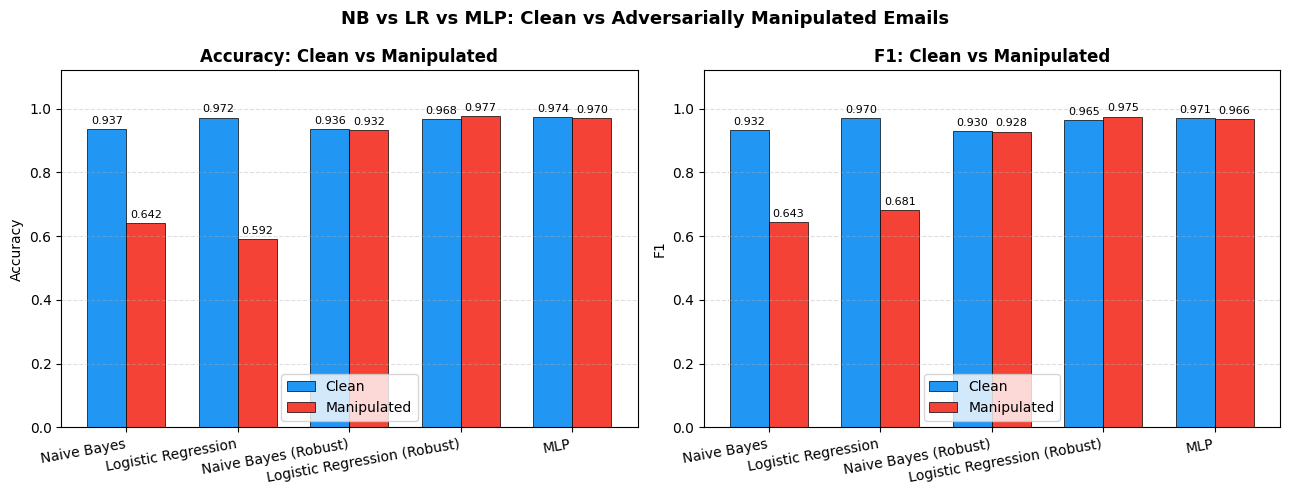

In [ ]:
# Bar chart
model_names = list(results_clean.keys())
x     = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1']):
    clean_vals = [results_clean[m][metric] for m in model_names]
    manip_vals = [results_manip[m][metric] for m in model_names]

    b1 = ax.bar(x - width/2, clean_vals, width, label='Clean',       color='#2196F3', edgecolor='black', linewidth=0.5)
    b2 = ax.bar(x + width/2, manip_vals, width, label='Manipulated', color='#F44336', edgecolor='black', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10, ha='right')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.12)
    ax.set_title(f'{metric}: Clean vs Manipulated', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('NB vs LR vs MLP: Clean vs Adversarially Manipulated Emails', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

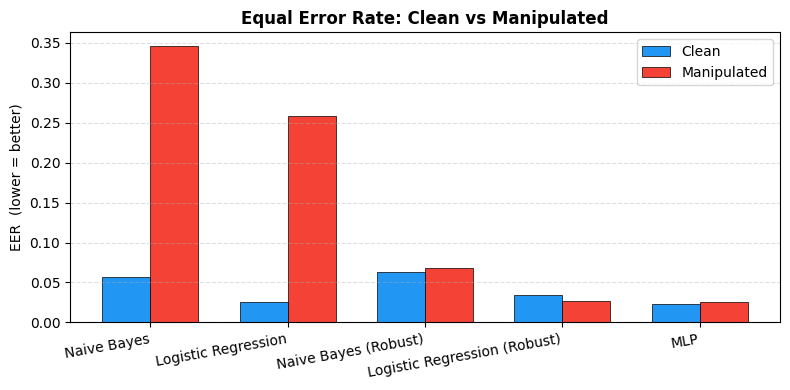

In [ ]:
# EER
eer_clean = [results_clean[m]['EER'] for m in model_names]
eer_manip = [results_manip[m]['EER'] for m in model_names]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, eer_clean, width, label='Clean',       color='#2196F3', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, eer_manip, width, label='Manipulated', color='#F44336', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right')
ax.set_ylabel('EER  (lower = better)')
ax.set_title('Equal Error Rate: Clean vs Manipulated', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('eer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary Tables
metric_cols = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC', 'EER']

clean_df = pd.DataFrame(results_clean).T[metric_cols]
manip_df = pd.DataFrame(results_manip).T[metric_cols]

print('\n' + '='*65)
print('  CLEAN EMAILS')
print('='*65)
print(clean_df.round(4).to_string())

print('\n' + '='*65)
print('  MANIPULATED EMAILS')
print('='*65)
print(manip_df.round(4).to_string())


  CLEAN EMAILS
                              Accuracy      F1  Precision  Recall     AUC     EER
Naive Bayes                     0.9369  0.9317     0.9177  0.9462  0.9842  0.0571
Logistic Regression             0.9718  0.9695     0.9542  0.9853  0.9970  0.0259
Naive Bayes (Robust)            0.9362  0.9304     0.9230  0.9380  0.9829  0.0626
Logistic Regression (Robust)    0.9681  0.9651     0.9597  0.9706  0.9959  0.0340
MLP                             0.9740  0.9713     0.9753  0.9674  0.9980  0.0231

  MANIPULATED EMAILS
                              Accuracy      F1  Precision  Recall     AUC     EER
Naive Bayes                     0.6417  0.6430     0.5878  0.7096  0.7330  0.3456
Logistic Regression             0.5920  0.6813     0.5283  0.9592  0.7998  0.2585
Naive Bayes (Robust)            0.9318  0.9277     0.8953  0.9625  0.9829  0.0680
Logistic Regression (Robust)    0.9770  0.9750     0.9649  0.9853  0.9972  0.0272
MLP                             0.9696  0.9664     0.9719  0

In [ ]:
# Adversarial email generator
import random

HOMOGLYPH_MAP = {
    'a': 'а', 'e': 'е', 'o': 'о', 'p': 'р',
    'c': 'с', 'x': 'х', 'i': 'і', 's': 'ѕ',
}

HAM_PHRASES = [
    'privacy policy', 'unsubscribe', 'disclaimer',
    'terms of service', 'you are receiving this because',
    'click here to unsubscribe', 'this is not spam',
    'safe and secure', 'your information is protected',
    'compliance', 'legal notice'
]

def apply_homoglyphs(text, severity=0.3):
    result = []
    for char in text:
        if char.lower() in HOMOGLYPH_MAP and random.random() < severity:
            result.append(HOMOGLYPH_MAP[char.lower()])
        else:
            result.append(char)
    return ''.join(result)

def apply_invisible_chars(text, severity=0.2):
    ZERO_WIDTH = '\u200b'
    result = []
    for char in text:
        result.append(char)
        if random.random() < severity:
            result.append(ZERO_WIDTH)
    return ''.join(result)

def apply_ham_injection(text, n_phrases=2):
    words = text.split()
    for _ in range(n_phrases):
        phrase = random.choice(HAM_PHRASES)
        position = random.randint(0, len(words))
        words.insert(position, phrase)
    return ' '.join(words)

def generate_adversarial_email(text, severity=0.3):
    text = apply_homoglyphs(text, severity=severity)
    text = apply_invisible_chars(text, severity=severity)
    text = apply_ham_injection(text, n_phrases=2)
    return text

random.seed(42)
X_test_adversarial      = np.array([generate_adversarial_email(t) for t in X_test_text])
X_test_adv_tfidf        = tfidf.transform(X_test_adversarial)
X_test_adv_robust_tfidf = tfidf_robust.transform(X_test_adversarial)

print(f'Adversarial test set size: {len(X_test_adversarial)}')

Adversarial test set size: 1348


In [ ]:
# # Naive Bayes adversarial
# nb_pred_adv = nb.predict(X_test_adv_tfidf)
# nb_prob_adv = nb.predict_proba(X_test_adv_tfidf)[:, 1]
# evaluate('Naive Bayes', y_test, nb_pred_adv, nb_prob_adv, split='adversarial')
# plot_cm(y_test, nb_pred_adv, 'Naive Bayes — Adversarial Emails')


=== Naive Bayes (Robust)  [ADVERSARIAL] ===
              precision    recall  f1-score   support

       Legit       1.00      0.16      0.28       735
    Phishing       0.50      1.00      0.67       613

    accuracy                           0.54      1348
   macro avg       0.75      0.58      0.47      1348
weighted avg       0.77      0.54      0.45      1348

AUC : 0.8920
EER : 0.1918  (lower is better)


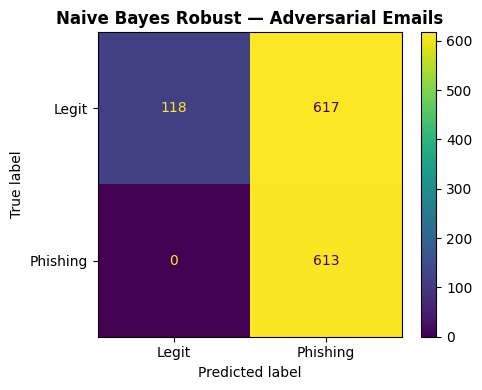

In [ ]:
# Naive Bayes Robust adversarial
nb_r_pred_adv = nb_robust.predict(X_test_adv_robust_tfidf)
nb_r_prob_adv = nb_robust.predict_proba(X_test_adv_robust_tfidf)[:, 1]
evaluate('Naive Bayes (Robust)', y_test, nb_r_pred_adv, nb_r_prob_adv, split='adversarial')
plot_cm(y_test, nb_r_pred_adv, 'Naive Bayes Robust — Adversarial Emails')

In [ ]:
# # Logistic Regression adversarial
# lr_pred_adv = lr.predict(X_test_adv_tfidf)
# lr_prob_adv = lr.predict_proba(X_test_adv_tfidf)[:, 1]
# evaluate('Logistic Regression', y_test, lr_pred_adv, lr_prob_adv, split='adversarial')
# plot_cm(y_test, lr_pred_adv, 'Logistic Regression — Adversarial Emails')


=== Logistic Regression (Robust)  [ADVERSARIAL] ===
              precision    recall  f1-score   support

       Legit       1.00      0.07      0.13       735
    Phishing       0.47      1.00      0.64       613

    accuracy                           0.49      1348
   macro avg       0.74      0.54      0.39      1348
weighted avg       0.76      0.49      0.36      1348

AUC : 0.9289
EER : 0.1524  (lower is better)


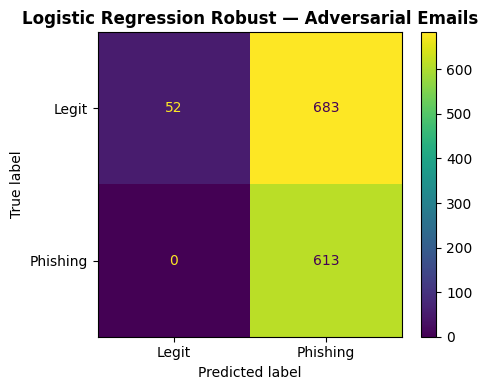

In [ ]:
#Logistic Regression Robust adversarial
lr_r_pred_adv = lr_robust.predict(X_test_adv_robust_tfidf)
lr_r_prob_adv = lr_robust.predict_proba(X_test_adv_robust_tfidf)[:, 1]
evaluate('Logistic Regression (Robust)', y_test, lr_r_pred_adv, lr_r_prob_adv, split='adversarial')
plot_cm(y_test, lr_r_pred_adv, 'Logistic Regression Robust — Adversarial Emails')

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=== MLP  [ADVERSARIAL] ===
              precision    recall  f1-score   support

       Legit       0.97      0.04      0.08       735
    Phishing       0.46      1.00      0.63       613

    accuracy                           0.48      1348
   macro avg       0.72      0.52      0.35      1348
weighted avg       0.74      0.48      0.33      1348

AUC : 0.7527
EER : 0.3007  (lower is better)


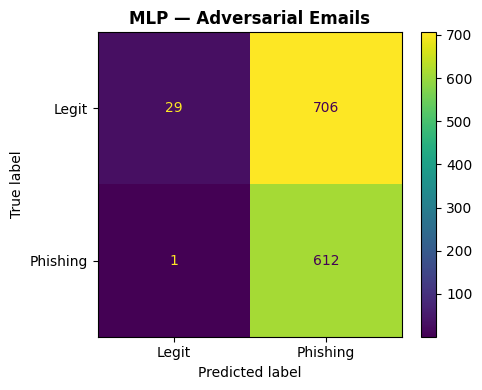

In [ ]:
# MLP adversarial
mlp_prob_adv = mlp_model.predict(X_test_adv_robust_tfidf.toarray()).flatten()
mlp_pred_adv = (mlp_prob_adv >= 0.5).astype(int)
evaluate('MLP', y_test, mlp_pred_adv, mlp_prob_adv, split='adversarial')
plot_cm(y_test, mlp_pred_adv, 'MLP — Adversarial Emails')

In [ ]:
# Save all results + plots to Drive
import json
import shutil
import os

# Save plots
drive_plots = '/content/drive/MyDrive/CS271/wing_plots/'
os.makedirs(drive_plots, exist_ok=True)

for fname in ['roc_curves_comparison.png', 'model_comparison_bar.png', 'eer_comparison.png']:
    if os.path.exists(fname):
        shutil.copy(fname, drive_plots + fname)
        print(f'Saved plot: {fname}')
    else:
        print(f'Plot not found: {fname}')

# Build results dict
wing_results = {
    'clean':            {},
    'manip':            {},
    'adversarial':      {},
    'training_history': {},
    'roc_curves':       {}
}

# Clean and manip from evaluate() dicts
for model, metrics in results_clean.items():
    wing_results['clean'][model] = {k: round(float(v), 4) for k, v in metrics.items()}

for model, metrics in results_manip.items():
    wing_results['manip'][model] = {k: round(float(v), 4) for k, v in metrics.items()}

# Adversarial from results_adv (fixed evaluate() now stores here)
for model, metrics in results_adv.items():
    wing_results['adversarial'][model] = {k: round(float(v), 4) for k, v in metrics.items()}

# MLP training history
wing_results['training_history']['MLP'] = {
    'accuracy':     [round(float(x), 4) for x in mlp_history.history['accuracy']],
    'val_accuracy': [round(float(x), 4) for x in mlp_history.history['val_accuracy']],
    'loss':         [round(float(x), 4) for x in mlp_history.history['loss']],
    'val_loss':     [round(float(x), 4) for x in mlp_history.history['val_loss']]
}

# ROC curves
for model_name, splits in roc_data.items():
    wing_results['roc_curves'][model_name] = {}
    for split_name, (fpr, tpr, roc_auc) in splits.items():
        wing_results['roc_curves'][model_name][split_name] = {
            'fpr': [round(float(x), 4) for x in fpr],
            'tpr': [round(float(x), 4) for x in tpr],
            'auc': round(float(roc_auc), 4)
        }

# Save JSON
save_path = '/content/drive/MyDrive/CS271/wing_results.json'
with open(save_path, 'w') as f:
    json.dump(wing_results, f, indent=2)

print('\nSaved to:', save_path)
print('Clean models:      ', list(wing_results['clean'].keys()))
print('Manip models:      ', list(wing_results['manip'].keys()))
print('Adversarial models:', list(wing_results['adversarial'].keys()))

# Verification
print('\nVERIFICATION — NB Robust accuracies:')
print('  Clean: ',       wing_results['clean'].get('Naive Bayes (Robust)', {}).get('Accuracy', 'missing'))
print('  Manip: ',       wing_results['manip'].get('Naive Bayes (Robust)', {}).get('Accuracy', 'missing'))
print('  Adversarial: ', wing_results['adversarial'].get('Naive Bayes (Robust)', {}).get('Accuracy', 'missing'))

Saved plot: roc_curves_comparison.png
Saved plot: model_comparison_bar.png
Saved plot: eer_comparison.png

Saved to: /content/drive/MyDrive/CS271/wing_results.json
Clean models:       ['Naive Bayes', 'Logistic Regression', 'Naive Bayes (Robust)', 'Logistic Regression (Robust)', 'MLP']
Manip models:       ['Naive Bayes', 'Logistic Regression', 'Naive Bayes (Robust)', 'Logistic Regression (Robust)', 'MLP']
Adversarial models: ['Naive Bayes (Robust)', 'Logistic Regression (Robust)', 'MLP']

VERIFICATION — NB Robust accuracies:
  Clean:  0.9362
  Manip:  0.9318
  Adversarial:  0.5423


In [ ]:
#  Full comparison table NB, LR, MLP
import pandas as pd

metric_cols = ['Accuracy', 'F1', 'AUC', 'EER']

clean_df = pd.DataFrame(wing_results['clean']).T[metric_cols]
manip_df = pd.DataFrame(wing_results['manip']).T[metric_cols]
adv_df   = pd.DataFrame(wing_results['adversarial']).T[metric_cols]

print('\n' + '='*65)
print('  CLEAN EMAILS')
print('='*65)
print(clean_df.round(4).to_string())

print('\n' + '='*65)
print('  CHAR SUBSTITUTION')
print('='*65)
print(manip_df.round(4).to_string())

print('\n' + '='*65)
print('  ADVERSARIAL ATTACK')
print('='*65)
print(adv_df.round(4).to_string())


  CLEAN EMAILS
                              Accuracy      F1     AUC     EER
Naive Bayes                     0.9369  0.9317  0.9842  0.0571
Logistic Regression             0.9718  0.9695  0.9970  0.0259
Naive Bayes (Robust)            0.9362  0.9304  0.9829  0.0626
Logistic Regression (Robust)    0.9681  0.9651  0.9959  0.0340
MLP                             0.9740  0.9713  0.9980  0.0231

  CHAR SUBSTITUTION
                              Accuracy      F1     AUC     EER
Naive Bayes                     0.6417  0.6430  0.7330  0.3456
Logistic Regression             0.5920  0.6813  0.7998  0.2585
Naive Bayes (Robust)            0.9318  0.9277  0.9829  0.0680
Logistic Regression (Robust)    0.9770  0.9750  0.9972  0.0272
MLP                             0.9696  0.9664  0.9974  0.0259

  ADVERSARIAL ATTACK
                              Accuracy      F1     AUC     EER
Naive Bayes (Robust)            0.5423  0.6652  0.8920  0.1918
Logistic Regression (Robust)    0.4933  0.6422  0.9289  0.1